     month     avg_DAU   MAU  stickiness_%
0  2024-01   91.548387   564         16.23
1  2024-02  286.517241  1189         24.10
2  2024-03  476.838710  1736         27.47
3  2024-04  535.933333  1558         34.40
4  2024-05  479.354839  1372         34.94
5  2024-06  473.133333  1308         36.17


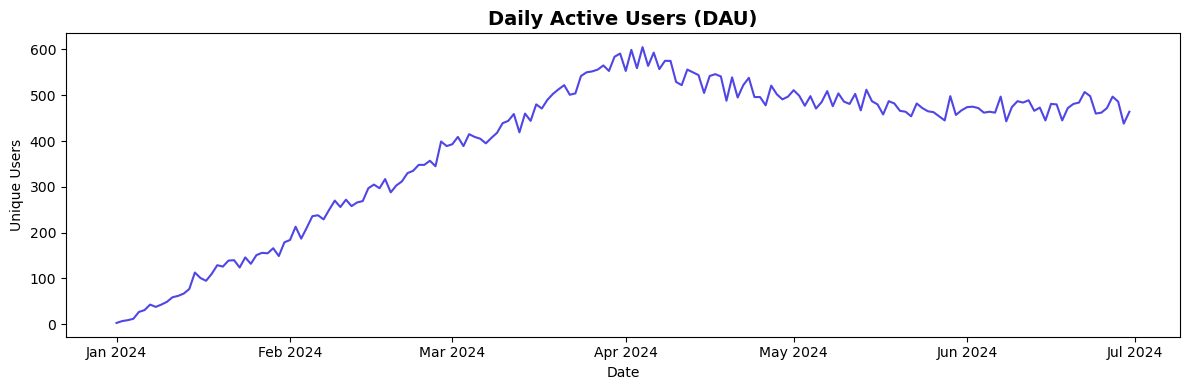

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv(r'C:\Users\Soumili Nag\OneDrive\Desktop\projects\SaaS Product Analytics\data\saas_events.csv', parse_dates=['event_date'])

# --- DAU ---
dau = df.groupby('event_date')['user_id'].nunique().reset_index()
dau.columns = ['date', 'DAU']

# --- WAU ---
df['week'] = df['event_date'].dt.to_period('W')
wau = df.groupby('week')['user_id'].nunique().reset_index()
wau.columns = ['week', 'WAU']

# --- MAU ---
df['month'] = df['event_date'].dt.to_period('M')
mau = df.groupby('month')['user_id'].nunique().reset_index()
mau.columns = ['month', 'MAU']

# --- Stickiness (DAU/MAU) ---
# Merge DAU and MAU on month
dau['month'] = dau['date'].dt.to_period('M')
dau_monthly_avg = dau.groupby('month')['DAU'].mean().reset_index()
dau_monthly_avg.columns = ['month', 'avg_DAU']
stickiness = dau_monthly_avg.merge(mau, on='month')
stickiness['stickiness_%'] = (stickiness['avg_DAU'] / stickiness['MAU'] * 100).round(2)

print(stickiness)

# --- Plot DAU ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dau['date'], dau['DAU'], color='#4F46E5', linewidth=1.5)
ax.set_title('Daily Active Users (DAU)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Unique Users')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(r'C:\Users\Soumili Nag\OneDrive\Desktop\projects\SaaS Product Analytics\images\dau_trend.png', dpi=150)
plt.show()